
════════════════════════════════════════════════════════════
  Доступные команды
════════════════════════════════════════════════════════════
  Сбор данных   : collect, collect_lstm, collect_lstm_phase
  Обучение      : train_wn, train_lstm, train_lstm_phase, train_cpg, train_all
  Ходьба        : walk, walk_wn, walk_lstm, walk_lstm_phase, walk_cpg
  Анализ        : compare, experiment
  Выход         : stop
════════════════════════════════════════════════════════════

─── Диагностика дисперсии ──────────────────────────────────────
  Сустав                                         Дисперсия  Статус
  ──────────────────────────────────────────────────────────────────────
  Head_S_1                                        0.00e+00  Неподвижен
  S_1_2                                           0.00e+00  Неподвижен
  S_2_3                                           0.00e+00  Неподвижен
  S_3_4                                           0.00e+00  Неподвижен
  S_4_LHip                          

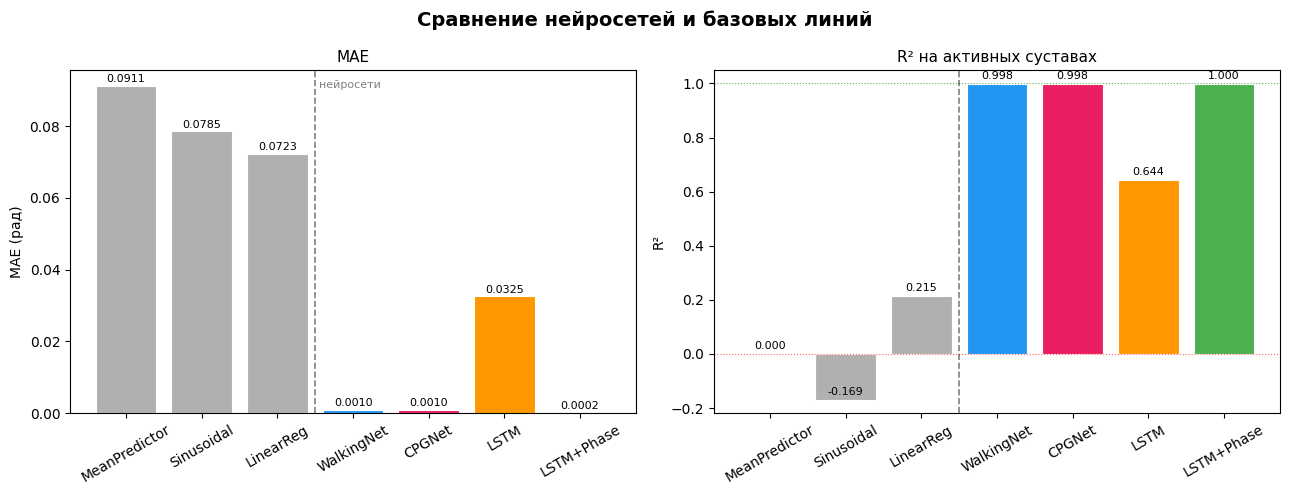

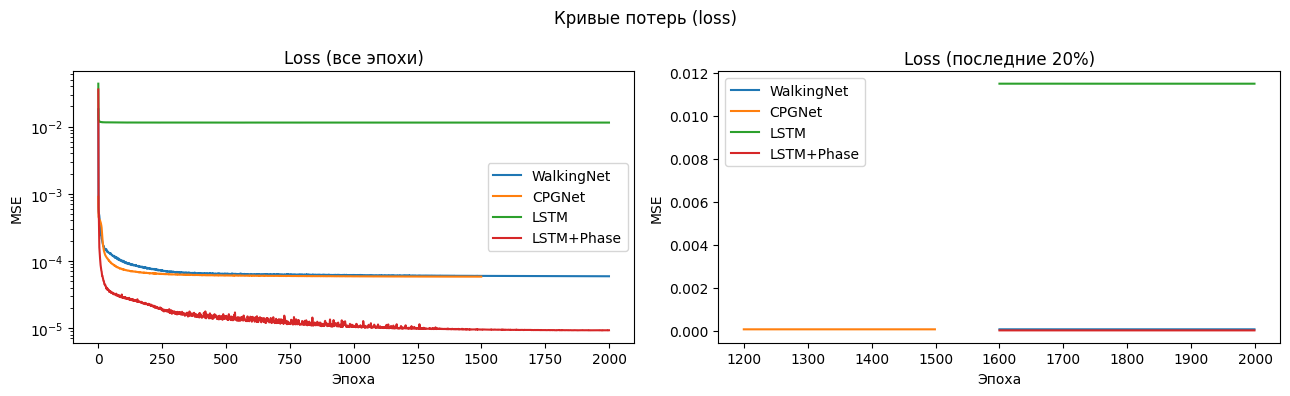

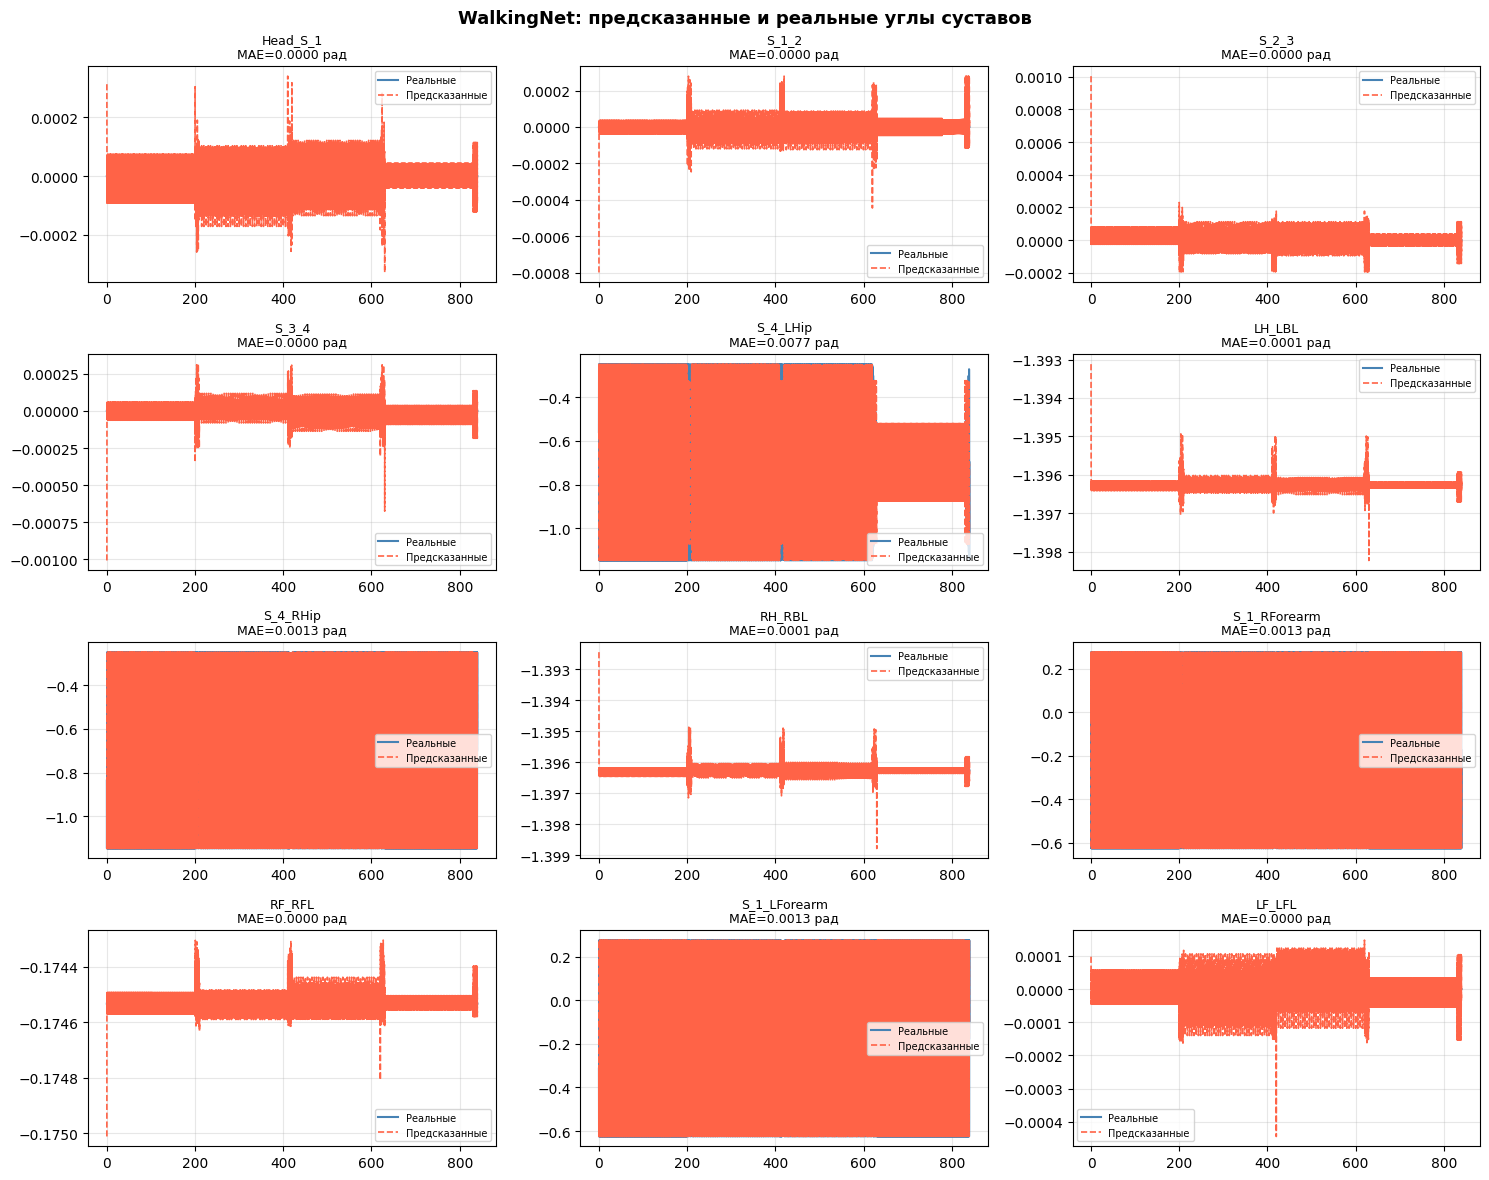

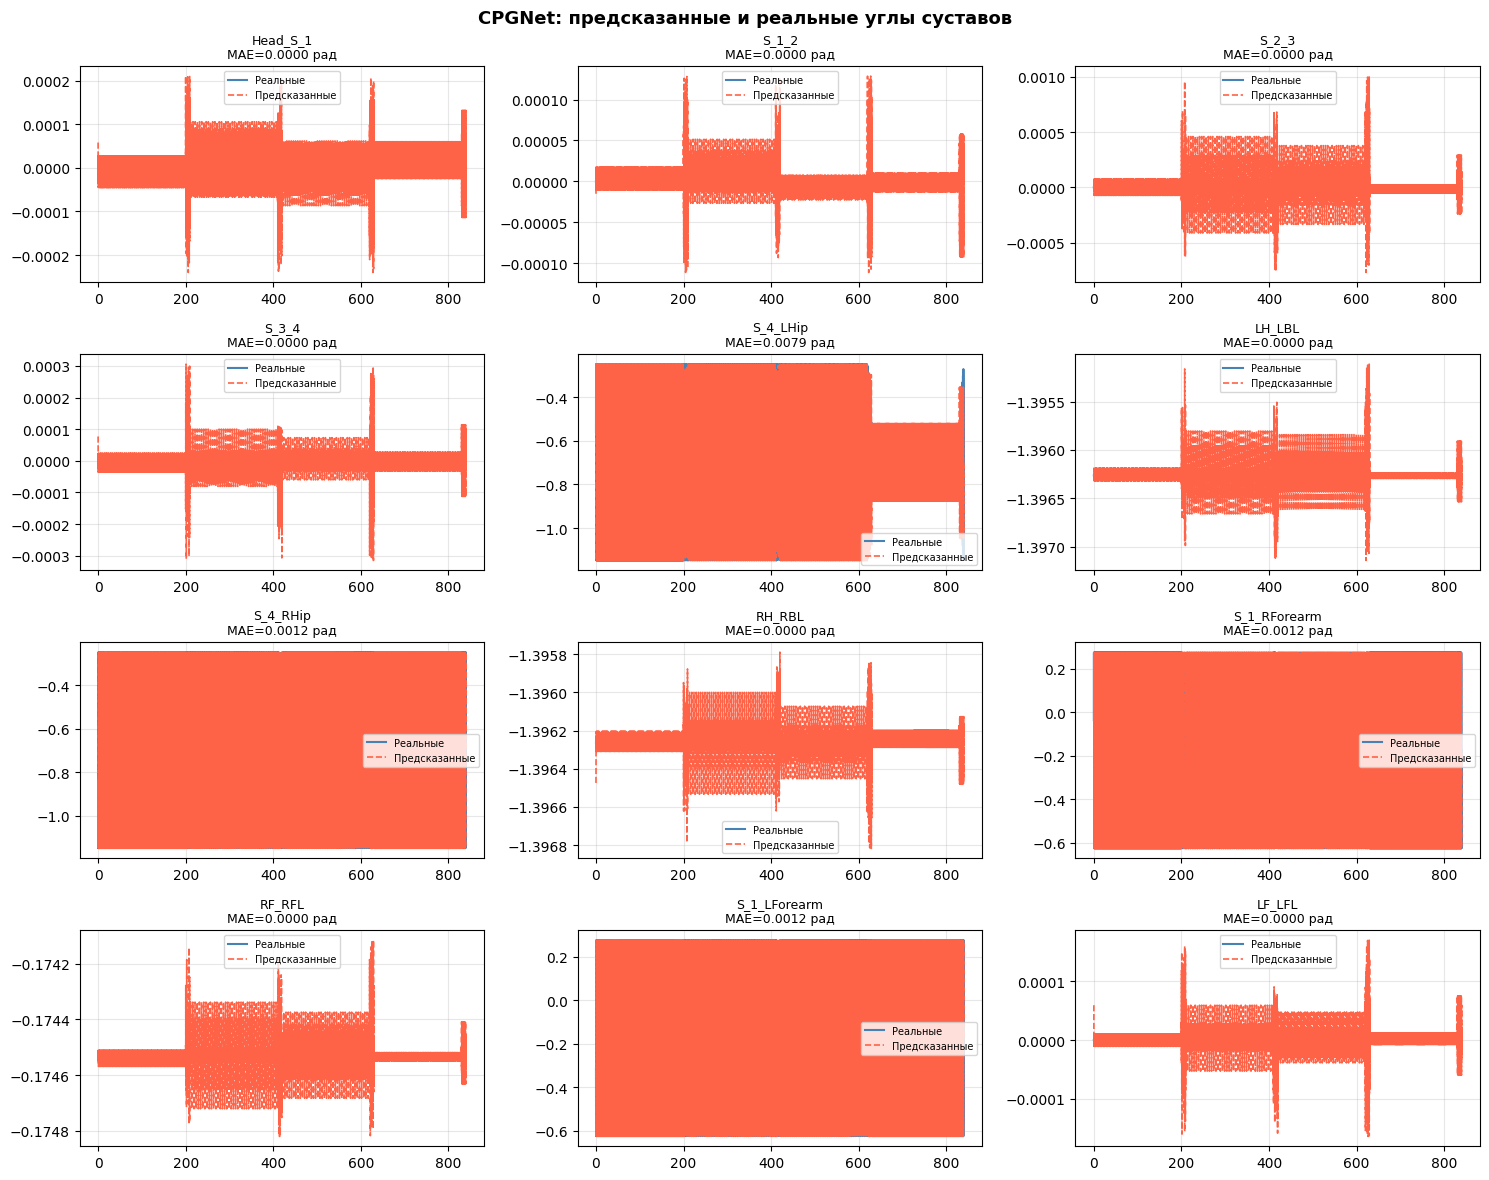

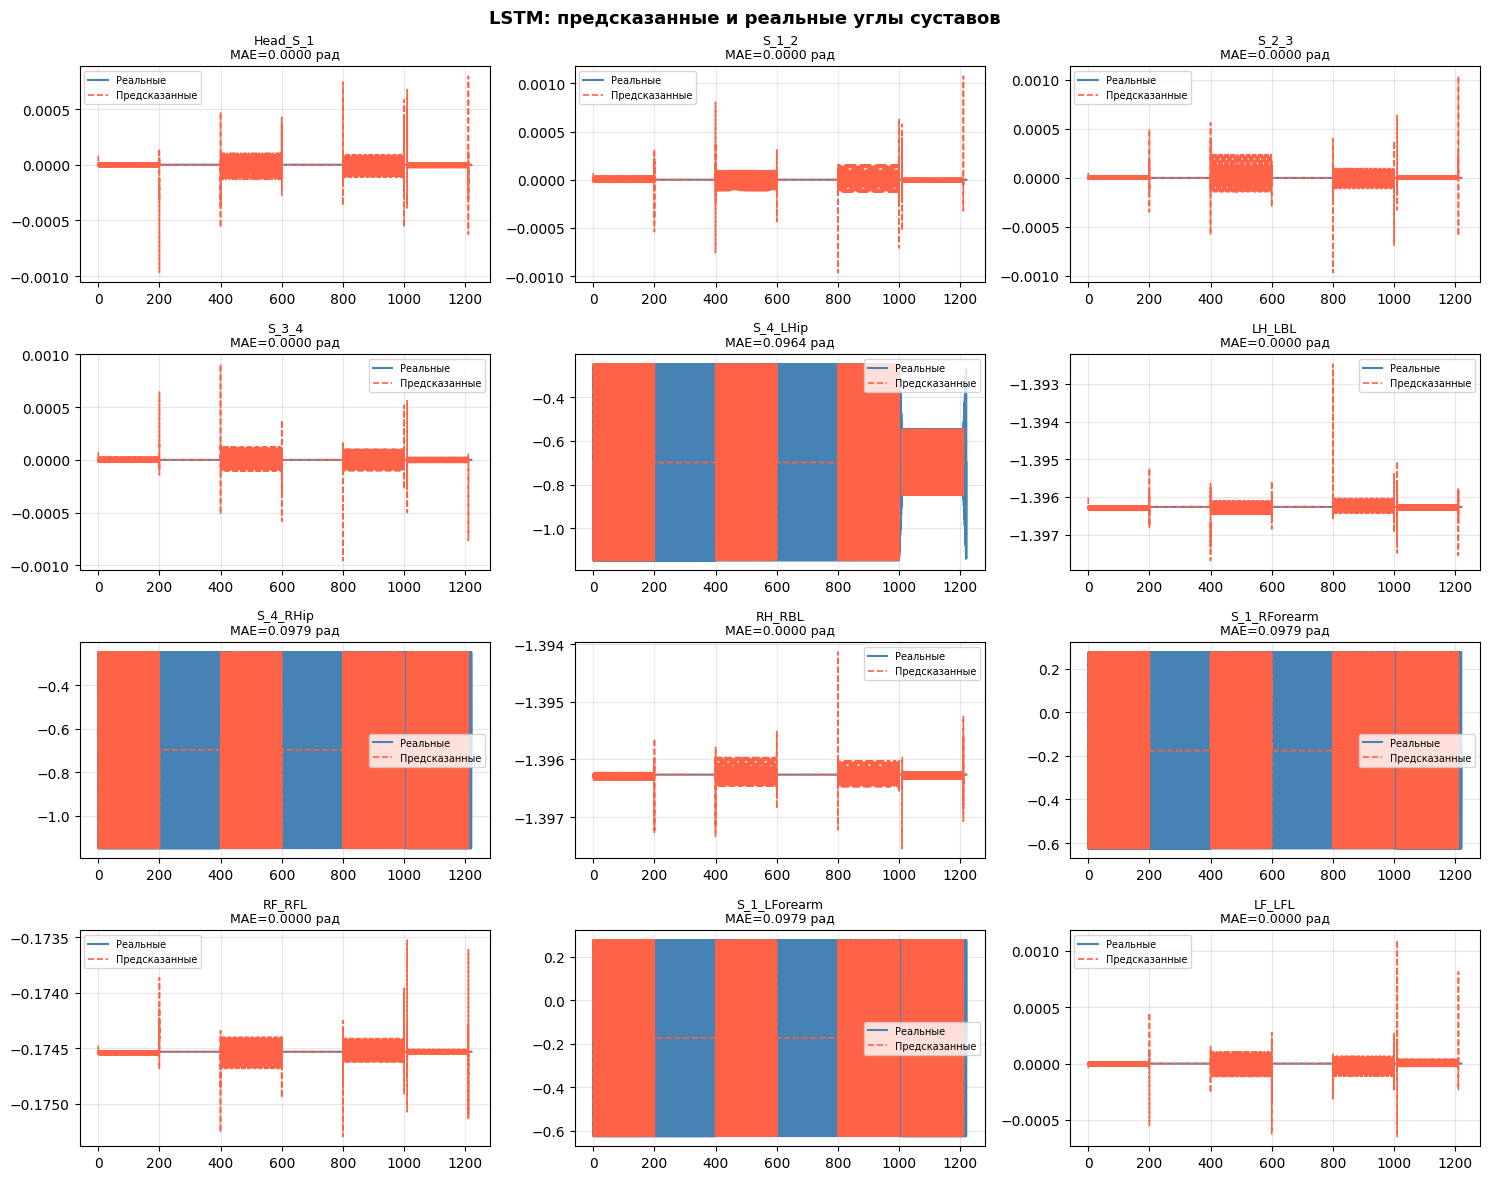

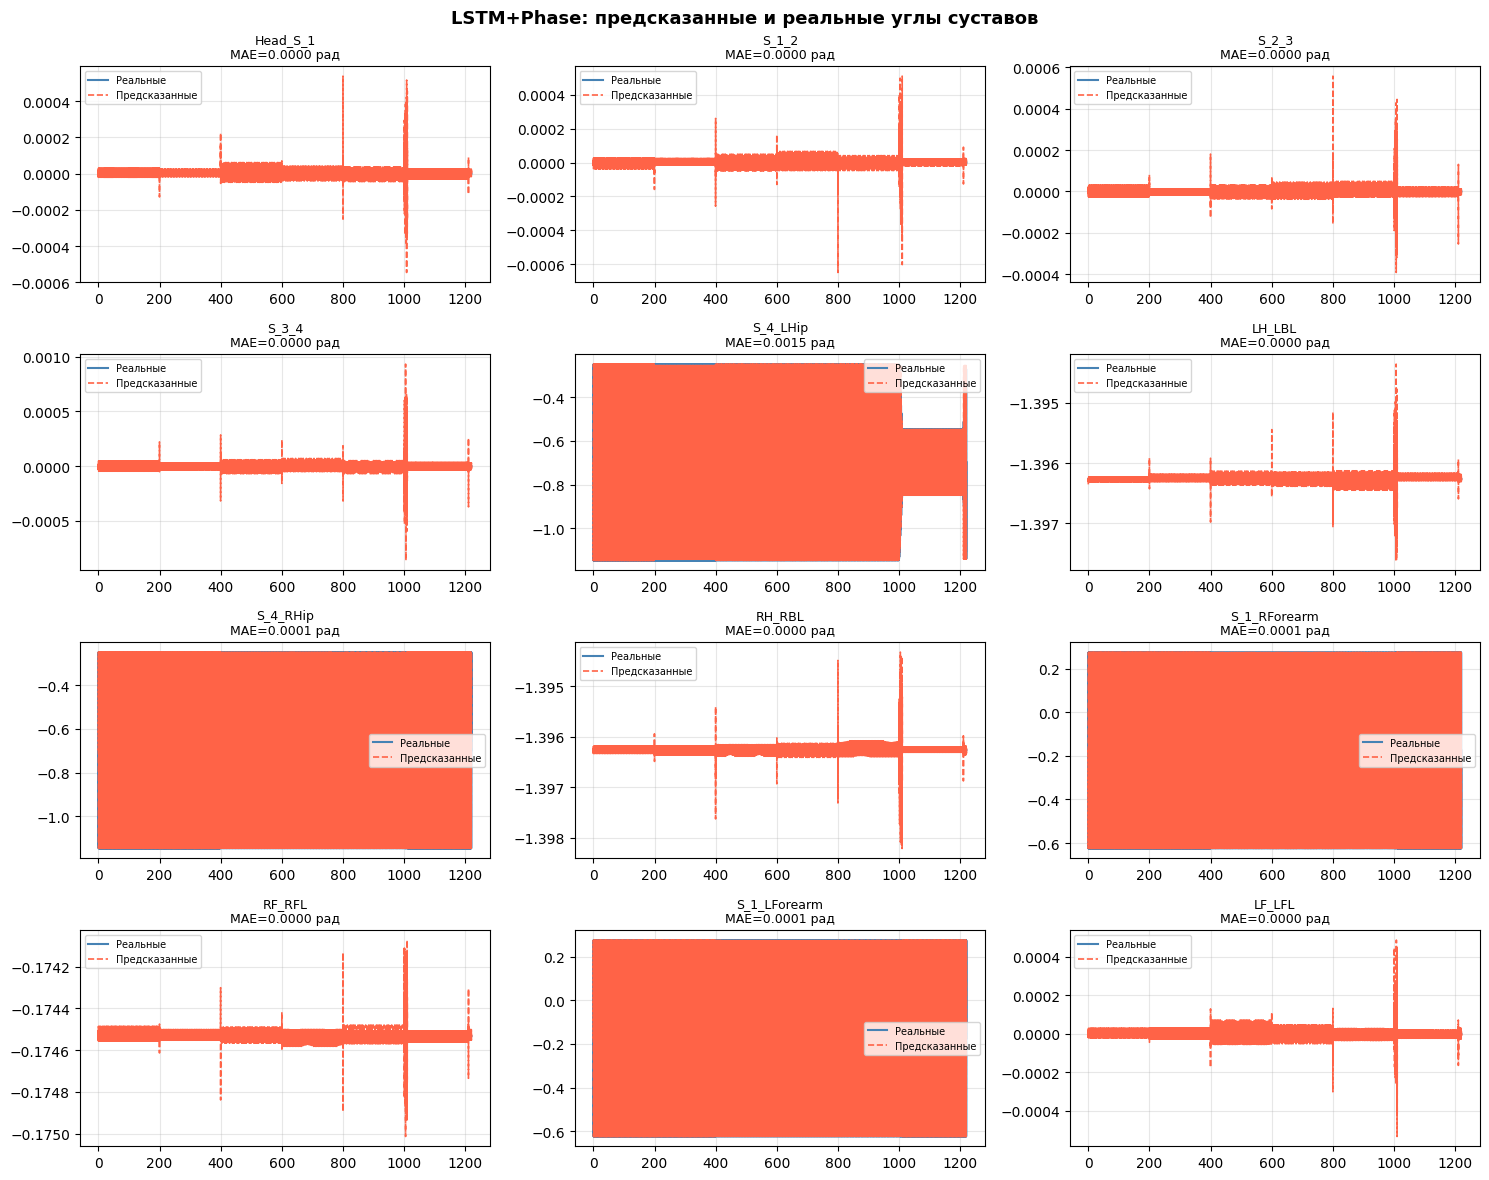

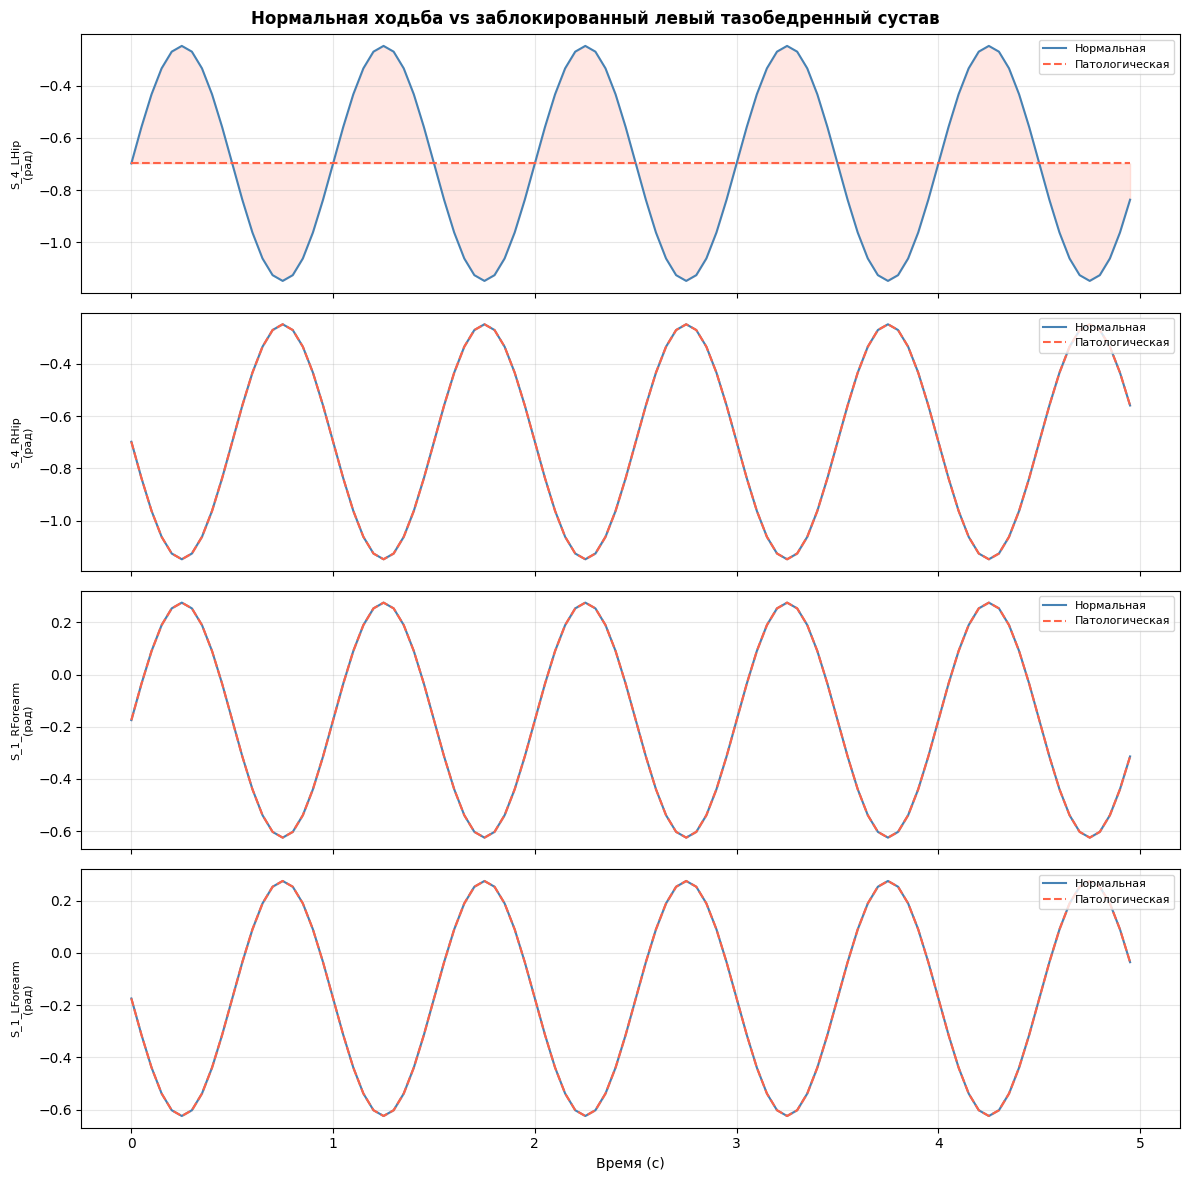

In [7]:
from coppeliasim_zmqremoteapi_client import RemoteAPIClient
import time
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import os
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

client = RemoteAPIClient('127.0.0.1', 23000)
sim = client.require('sim')

joint_names = [
    'Revolute_Head_Spine_1', 'Revolute_Spine_1_2', 'Revolute_Spine_2_3',
    'Revolute_Spine_3_4', 'Revolute_Spine_4_LHip', 'Revolute_LH_LBL',
    'Revolute_Spine_4_RHip', 'Revolute_RH_RBL', 'Revolute_Spine_1_RForearm',
    'Revolute_RF_RFL', 'Revolute_Spine_1_LForearm', 'Revolute_LF_LFL',
]

joint_handles = {name: sim.getObjectHandle(name) for name in joint_names}
main_handle = sim.getObjectHandle('Spine_1')

joint_amp = {
    'Revolute_Head_Spine_1': 0.00, 'Revolute_Spine_1_2': 0.00,
    'Revolute_Spine_2_3': 0.00, 'Revolute_Spine_3_4': 0.00,
    'Revolute_Spine_4_LHip': -0.45, 'Revolute_LH_LBL': 0.00,
    'Revolute_Spine_4_RHip': -0.45, 'Revolute_RH_RBL': 0.00,
    'Revolute_Spine_1_LForearm': -0.45, 'Revolute_LF_LFL': 0.00,
    'Revolute_Spine_1_RForearm': -0.45, 'Revolute_RF_RFL': 0.00
}

joint_phase = {
    'Revolute_Head_Spine_1': 0.00, 'Revolute_Spine_1_2': 0.00,
    'Revolute_Spine_2_3': 0.00, 'Revolute_Spine_3_4': 0.00,
    'Revolute_Spine_4_LHip': np.pi, 'Revolute_LH_LBL': 0.00,
    'Revolute_Spine_4_RHip': 0.00, 'Revolute_RH_RBL': 0.00,
    'Revolute_Spine_1_LForearm': 0.00, 'Revolute_LF_LFL': 0.00,
    'Revolute_Spine_1_RForearm': np.pi, 'Revolute_RF_RFL': 0.00
}

joint_limits = {
    'Revolute_Head_Spine_1': (0.0, 0.0), 'Revolute_Spine_1_2': (0.0, 0.0),
    'Revolute_Spine_2_3': (0.0, 0.0), 'Revolute_Spine_3_4': (0.0, 0.0),
    'Revolute_Spine_4_LHip': (-1.2, 1.2), 'Revolute_LH_LBL': (0.0, 0.0),
    'Revolute_Spine_4_RHip': (-1.2, 1.2), 'Revolute_RH_RBL': (0.0, 0.0),
    'Revolute_Spine_1_LForearm': (-1.2, 1.2), 'Revolute_LF_LFL': (0.0, 0.0),
    'Revolute_Spine_1_RForearm': (-1.2, 1.2), 'Revolute_RF_RFL': (0.0, 0.0)
}

gait_freq = 1.0
step_length = 0.01
step_dt = 0.05
seq_len = 10

joint_rest = {
    name: float(sim.getJointPosition(joint_handles[name]))
    for name in joint_names
}

# Вспомогательные функции
def sinusoidal_targets(t: float, amp_override: dict = None) -> np.ndarray:
    amp = amp_override if amp_override is not None else joint_amp
    out = np.zeros(len(joint_names))
    for i, name in enumerate(joint_names):
        a = amp.get(name, joint_amp[name])
        out[i] = joint_rest[name] + a * np.sin(2 * np.pi * gait_freq * t + joint_phase[name])
    return out

def get_state_with_phase(t: float) -> np.ndarray:
    positions = np.array([float(sim.getJointPosition(joint_handles[n])) for n in joint_names])
    phase = 2 * np.pi * gait_freq * t
    return np.concatenate([positions, [np.sin(phase), np.cos(phase)]])

def set_joint(name: str, value: float) -> None:
    sim.setJointTargetPosition(joint_handles[name], float(value))

def apply_targets(targets: np.ndarray) -> None:
    for i, name in enumerate(joint_names):
        low, high = joint_limits[name]
        set_joint(name, float(np.clip(targets[i], low, high)))

def set_object_position(offset: float, base_pos: list) -> None:
    sim.setObjectPosition(main_handle, -1,
        [float(base_pos[0] + offset), float(base_pos[1]), float(base_pos[2])])

# Ходьба без применения нейронной сети
def walk(n_steps: int = 100):
    sim.startSimulation()
    pos = sim.getObjectPosition(main_handle)
    forward_offset = 0.0
    t = 0.0
    for _ in range(n_steps):
        apply_targets(sinusoidal_targets(t))
        time.sleep(step_dt)
        forward_offset += step_length
        set_object_position(forward_offset, pos)
        t += step_dt


# Сбор данных
def _collect_episode(n_steps: int, amp_override: dict = None, freq_override: float = None, label: str = "", history: list = None, with_phase: bool = False) -> tuple:
    global gait_freq
    orig_freq = gait_freq
    if freq_override is not None:
        gait_freq = freq_override
    lstm_mode = history is not None
    if history is None:
        history = []
    buf = []
    sim.startSimulation()
    t = 0.0
    for step in range(n_steps):
        if lstm_mode:
            if with_phase:
                frame = get_state_with_phase(t)
            else:
                frame = np.array([
                    float(sim.getJointPosition(joint_handles[n]))
                    for n in joint_names])
            history.append(frame)
            if len(history) >= seq_len:
                buf.append({
                    'input': np.stack(history[-seq_len:], axis=0),
                    'output': sinusoidal_targets(t + step_dt, amp_override=amp_override),
                })
        else:
            buf.append({
                'input': get_state_with_phase(t),
                'output': sinusoidal_targets(t + step_dt, amp_override=amp_override),
            })
        apply_targets(sinusoidal_targets(t, amp_override=amp_override))
        time.sleep(step_dt)
        t += step_dt
    sim.stopSimulation()
    gait_freq = orig_freq
    return buf, history[-seq_len:] if history else []

def _collect_transition(n_steps: int, freq_from: float, freq_to: float, amp_from: dict = None, amp_to: dict = None, label: str = "", history: list = None, with_phase: bool = False) -> tuple:
    global gait_freq
    orig_freq = gait_freq
    if amp_from is None: amp_from = dict(joint_amp)
    if amp_to is None: amp_to = dict(joint_amp)
    lstm_mode = history is not None
    if history is None: history = []
    buf = []
    sim.startSimulation()
    t = 0.0
    for step in range(n_steps):
        alpha = step / max(n_steps - 1, 1)
        gait_freq = freq_from + alpha * (freq_to - freq_from)
        interp_amp = {
            name: amp_from[name] + alpha * (amp_to[name] - amp_from[name])
            for name in joint_names
        }
        if lstm_mode:
            if with_phase:
                frame = get_state_with_phase(t)
            else:
                frame = np.array([
                    float(sim.getJointPosition(joint_handles[n]))
                    for n in joint_names])
            history.append(frame)
            if len(history) >= seq_len:
                buf.append({
                    'input':  np.stack(history[-seq_len:], axis=0),
                    'output': sinusoidal_targets(t + step_dt, amp_override=interp_amp),
                })
        else:
            buf.append({
                'input':  get_state_with_phase(t),
                'output': sinusoidal_targets(t + step_dt, amp_override=interp_amp),
            })
        apply_targets(sinusoidal_targets(t, amp_override=interp_amp))
        time.sleep(step_dt)
        t += step_dt
    sim.stopSimulation()
    gait_freq = orig_freq
    return buf, history[-seq_len:] if history else []

def walk_with_data_collection(n_steps: int = 4000, n_transition: int = 200):
    global data_buffer
    data_buffer = []
    limp_amp = dict(joint_amp)
    limp_amp['Revolute_Spine_4_LHip'] = -0.15
    limp_amp['Revolute_LH_LBL'] = 0.00
    buf, _ = _collect_episode(n_steps, freq_override=1.0, label="Нормальная ходьба")
    data_buffer += buf
    buf, _ = _collect_transition(n_transition, 1.0, 0.6, label="1.0->0.6")
    data_buffer += buf
    buf, _ = _collect_episode(n_steps, freq_override=0.6, label="Медленная ходьба")
    data_buffer += buf
    buf, _ = _collect_transition(n_transition, 0.6, 1.4, label="0.6->1.4")
    data_buffer += buf
    buf, _ = _collect_episode(n_steps, freq_override=1.4, label="Быстрая ходьба")
    data_buffer += buf
    buf, _ = _collect_transition(n_transition, 1.4, 1.0, amp_from=dict(joint_amp), amp_to=limp_amp, label="1.4->хромота")
    data_buffer += buf
    buf, _ = _collect_episode(n_steps, amp_override=limp_amp, freq_override=1.0, label="Асимметричная ходьба")
    data_buffer += buf
    buf, _ = _collect_transition(n_transition, 1.0, 1.0, amp_from=limp_amp, amp_to=dict(joint_amp), label="хромота->нормальная")
    data_buffer += buf
    with open('walking_data.pkl', 'wb') as f:
        pickle.dump(data_buffer, f)

def _collect_lstm_dataset(pkl_file: str, with_phase: bool, n_steps: int = 4000, n_transition: int = 200):
    global data_buffer
    data_buffer = []
    limp_amp = dict(joint_amp)
    limp_amp['Revolute_Spine_4_LHip'] = -0.15
    history = []
    episodes = [
        (dict(joint_amp), 1.0, 1.0,  None, None, "Нормальная ходьба"),
        (None, 1.0, 0.6, None, None, "1.0->0.6 (переход)"),
        (dict(joint_amp), 0.6, 0.6, None, None, "Медленная ходьба"),
        (None, 0.6, 1.4, None, None, "0.6->1.4 (переход)"),
        (dict(joint_amp), 1.4, 1.4,  None, None, "Быстрая ходьба"),
        (None, 1.4, 1.0, dict(joint_amp),limp_amp, "1.4->хромота (переход)"),
        (limp_amp, 1.0, 1.0, None, None, "Асимметричная ходьба"),
        (None, 1.0, 1.0, limp_amp, dict(joint_amp),"хромота->нормальная (переход)"),
    ]
    for amp_ov, freq_from, freq_to, amp_from, amp_to, label in episodes:
        is_transition = (amp_from is not None)
        kw = dict(label=label, history=history, with_phase=with_phase)
        if is_transition:
            buf, history = _collect_transition(n_transition, freq_from, freq_to, amp_from=amp_from, amp_to=amp_to, **kw)
        else:
            buf, history = _collect_episode(n_steps, amp_override=amp_ov, freq_override=freq_from, **kw)
        data_buffer += buf
    with open(pkl_file, 'wb') as f:
        pickle.dump(data_buffer, f)

def walk_with_data_collection_lstm(n_steps: int = 4000, n_transition: int = 200):
    _collect_lstm_dataset('walking_data_lstm.pkl', with_phase=False, n_steps=n_steps, n_transition=n_transition)

def walk_with_data_collection_lstm_phase(n_steps: int = 4000, n_transition: int = 200):
    _collect_lstm_dataset('walking_data_lstm_phase.pkl', with_phase=True, n_steps=n_steps, n_transition=n_transition)


# Архитектуры нейронных сетей
class WalkingNet(nn.Module):
    def __init__(self, input_size: int = 14, output_size: int = 12):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, 128), nn.Tanh(),
            nn.Linear(128, output_size)
        )
    def forward(self, x):
        return self.net(x)

class WalkingLSTM(nn.Module):
    def __init__(self, input_size: int = 12, hidden_size: int = 128, num_layers: int = 2, output_size: int = 12):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.1)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64), nn.Tanh(),
            nn.Linear(64, output_size)
        )
    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)
        return self.head(out[:, -1, :]), hidden

class WalkingLSTM_Phase(nn.Module):
    def __init__(self, input_size: int = 14, hidden_size: int = 128, num_layers: int = 2, output_size: int = 12):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.1)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64), nn.Tanh(),
            nn.Linear(64, output_size)
        )
    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)
        return self.head(out[:, -1, :]), hidden

class CPGNet(nn.Module):
    def __init__(self, state_size: int = 14, output_size: int = 12, correction_scale: float = 0.3):
        super().__init__()
        self.correction_scale = correction_scale
        self.corrector = nn.Sequential(
            nn.Linear(state_size, 128), nn.Tanh(),
            nn.Linear(128, 64), nn.Tanh(),
            nn.Linear(64, output_size), nn.Tanh()
        )
    def forward(self, state, cpg_target):
        return cpg_target + self.corrector(state) * self.correction_scale


# Обучение
def _load_flat_data(pkl_file: str):
    data = pickle.load(open(pkl_file, 'rb'))
    inputs  = torch.tensor(np.stack([d['input']  for d in data]), dtype=torch.float32)
    targets = torch.tensor(np.stack([d['output'] for d in data]), dtype=torch.float32)
    mean = inputs.mean(dim=0)
    std  = inputs.std(dim=0).clamp(min=1e-6)
    return inputs, targets, mean, std

def _train_loop(model, loader, epochs, lr, dataset_len, label):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    history = []
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for batch in loader:
            xb = batch[0]
            yb = batch[-1]
            optimizer.zero_grad()
            if isinstance(model, (WalkingLSTM, WalkingLSTM_Phase)):
                pred, _ = model(xb)
            elif isinstance(model, CPGNet):
                pred = model(xb, batch[1])
            else:
                pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        scheduler.step()
        avg = epoch_loss / dataset_len
        history.append(avg)
        if epoch % 200 == 0:
            print(f"[{label}] Epoch {epoch:4d}  loss={avg:.6f}"
                  f"  lr={scheduler.get_last_lr()[0]:.2e}")
    return history

def _train_lstm_common(pkl_file: str, model: nn.Module, pth_file: str, label: str, epochs: int = 2000, batch_size: int = 64, lr: float = 3e-4):
    if not os.path.exists(pkl_file):
        print(f"Нет {pkl_file}."); return
    data = pickle.load(open(pkl_file, 'rb'))
    inputs = torch.tensor(np.stack([d['input']  for d in data]), dtype=torch.float32)
    targets = torch.tensor(np.stack([d['output'] for d in data]), dtype=torch.float32)
    flat = inputs.reshape(-1, inputs.shape[-1])
    mean = flat.mean(dim=0)
    std = flat.std(dim=0).clamp(min=1e-6)
    inputs_n = (inputs - mean) / std
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(inputs_n, targets), batch_size=batch_size, shuffle=True)
    history = _train_loop(model, loader, epochs, lr, len(inputs), label)
    torch.save({'model': model.state_dict(), 'input_mean': mean, 'input_std': std, 'loss_history': history}, pth_file)
    return model, history

def train_walkingnet(epochs=2000, batch_size=64, lr=3e-4):
    if not os.path.exists('walking_data.pkl'):
        print("Нет walking_data.pkl."); return
    inputs, targets, mean, std = _load_flat_data('walking_data.pkl')
    inputs_n = (inputs - mean) / std
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(inputs_n, targets), batch_size=batch_size, shuffle=True)
    model = WalkingNet()
    history = _train_loop(model, loader, epochs, lr, len(inputs), 'WalkingNet')
    torch.save({'model': model.state_dict(), 'input_mean': mean, 'input_std': std, 'loss_history': history}, 'walking_model.pth')
    return model, history

def train_lstm(epochs=2000, batch_size=64, lr=3e-4):
    return _train_lstm_common('walking_data_lstm.pkl', WalkingLSTM(), 'walking_lstm.pth', 'LSTM', epochs, batch_size, lr)

def train_lstm_phase(epochs=2000, batch_size=64, lr=3e-4):
    return _train_lstm_common('walking_data_lstm_phase.pkl', WalkingLSTM_Phase(), 'walking_lstm_phase.pth', 'LSTM+Phase', epochs, batch_size, lr)

def train_cpg(epochs=1500, batch_size=64, lr=3e-4):
    if not os.path.exists('walking_data.pkl'):
        print("Нет walking_data.pkl."); return
    inputs, targets, mean, std = _load_flat_data('walking_data.pkl')
    inputs_n = (inputs - mean) / std
    phases = torch.atan2(inputs[:, -2], inputs[:, -1])
    ts = (phases / (2 * np.pi * gait_freq)).numpy()
    cpg_basis = torch.tensor(np.stack([sinusoidal_targets(float(t)) for t in ts]), dtype=torch.float32)
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(inputs_n, cpg_basis, targets), batch_size=batch_size, shuffle=True)
    model = CPGNet()
    history = _train_loop(model, loader, epochs, lr, len(inputs), 'CPGNet')
    torch.save({'model': model.state_dict(), 'input_mean': mean, 'input_std': std, 'loss_history': history}, 'walking_cpg.pth')
    return model, history

def train_all():
    print("═" * 60)
    print("1 WalkingNet"); print("═" * 60)
    train_walkingnet()
    print("\n" + "═" * 60)
    print("2 LSTM (без фазы)"); print("═" * 60)
    train_lstm()
    print("\n" + "═" * 60)
    print("3 LSTM (с фазой)"); print("═" * 60)
    train_lstm_phase()
    print("\n" + "═" * 60)
    print("4 CPGNet"); print("═" * 60)
    train_cpg()


# Ходьба с нейросетями
def _walk_common(model, mean, std, use_phase: bool, n_steps: int = 40, use_cpg: bool = False):
    sim.startSimulation()
    pos = sim.getObjectPosition(main_handle)
    forward_offset, t = 0.0, 0.0
    history, hidden = [], None
    try:
        for step in range(n_steps):
            if use_cpg:
                state   = torch.tensor(get_state_with_phase(t), dtype=torch.float32).unsqueeze(0)
                cpg_tgt = torch.tensor(sinusoidal_targets(t), dtype=torch.float32).unsqueeze(0)
                with torch.no_grad():
                    pred = model((state - mean) / std, cpg_tgt).numpy().flatten()
            elif use_phase:
                frame = get_state_with_phase(t)
                history.append(frame)
                if len(history) < seq_len:
                    apply_targets(sinusoidal_targets(t))
                    time.sleep(step_dt)
                    forward_offset += step_length
                    set_object_position(forward_offset, pos)
                    t += step_dt
                    continue
                seq = np.stack(history[-seq_len:], axis=0)
                inp = torch.tensor(seq, dtype=torch.float32).unsqueeze(0)
                inp = (inp - mean) / std
                with torch.no_grad():
                    pred, hidden = model(inp, hidden)
                pred = pred.numpy().flatten()
            elif isinstance(model, WalkingLSTM):
                current = np.array([
                    float(sim.getJointPosition(joint_handles[n]))
                    for n in joint_names])
                history.append(current)
                if len(history) < seq_len:
                    apply_targets(sinusoidal_targets(t))
                    time.sleep(step_dt)
                    forward_offset += step_length
                    set_object_position(forward_offset, pos)
                    t += step_dt
                    continue
                seq = np.stack(history[-seq_len:], axis=0)
                inp = torch.tensor(seq, dtype=torch.float32).unsqueeze(0)
                inp = (inp - mean) / std
                with torch.no_grad():
                    pred, hidden = model(inp, hidden)
                pred = pred.numpy().flatten()
            else:
                state = torch.tensor(get_state_with_phase(t), dtype=torch.float32).unsqueeze(0)
                with torch.no_grad():
                    pred = model((state - mean) / std).numpy().flatten()
            apply_targets(pred)
            time.sleep(step_dt)
            forward_offset += step_length
            set_object_position(forward_offset, pos)
            t += step_dt
    except Exception as e:
        print(f"Ошибка: {e}")
    finally:
        sim.stopSimulation()
        print("Ходьба завершена.")

def walk_with_wn(n_steps: int = 40):
    if not os.path.exists('walking_model.pth'):
        print("Нет walking_model.pth."); return
    ckpt  = torch.load('walking_model.pth', weights_only=True)
    model = WalkingNet(); model.load_state_dict(ckpt['model']); model.eval()
    _walk_common(model, ckpt['input_mean'], ckpt['input_std'], use_phase=False, n_steps=n_steps)

def walk_with_lstm(n_steps: int = 40):
    if not os.path.exists('walking_lstm.pth'):
        print("Нет walking_lstm.pth."); return
    ckpt  = torch.load('walking_lstm.pth', weights_only=True)
    model = WalkingLSTM(); model.load_state_dict(ckpt['model']); model.eval()
    _walk_common(model, ckpt['input_mean'], ckpt['input_std'], use_phase=False, n_steps=n_steps)

def walk_with_lstm_phase(n_steps: int = 40):
    if not os.path.exists('walking_lstm_phase.pth'):
        print("Нет walking_lstm_phase.pth. Запустите train_lstm_phase."); return
    ckpt  = torch.load('walking_lstm_phase.pth', weights_only=True)
    model = WalkingLSTM_Phase()
    model.load_state_dict(ckpt['model']); model.eval()
    _walk_common(model, ckpt['input_mean'], ckpt['input_std'], use_phase=True, n_steps=n_steps)

def walk_with_cpg(n_steps: int = 40):
    if not os.path.exists('walking_cpg.pth'):
        print("Нет walking_cpg.pth."); return
    ckpt  = torch.load('walking_cpg.pth', weights_only=True)
    model = CPGNet(); model.load_state_dict(ckpt['model']); model.eval()
    _walk_common(model, ckpt['input_mean'], ckpt['input_std'], use_phase=False, n_steps=n_steps, use_cpg=True)


# Аналитика
def experiment_normal_vs_pathological(n_steps: int = 100):
    t_arr = np.arange(n_steps) * step_dt
    normal = np.stack([sinusoidal_targets(t) for t in t_arr])
    limp_amp = dict(joint_amp)
    limp_amp['Revolute_Spine_4_LHip'] = 0.0
    pathological = np.stack([sinusoidal_targets(t, amp_override=limp_amp) for t in t_arr])
    diff = pathological - normal
    active_idx = [i for i, n in enumerate(joint_names) if joint_amp[n] != 0.0]
    active_names = [joint_names[i] for i in active_idx]
    print(f"\n{'Сустав':42s}  {'MAE (рад)':>10}  {'Max (рад)':>14}")
    print("─" * 70)
    for i, name in zip(active_idx, active_names):
        mae = np.abs(diff[:, i]).mean()
        maxerr = np.abs(diff[:, i]).max()
        flag = " ← заблокирован" if 'LHip' in name else ""
        print(f"{name:42s}  {mae:10.4f}  {maxerr:14.4f}{flag}")
    print(f"\nСуммарная MAE (все суставы): {np.abs(diff).mean():.4f} рад")
    n_active = len(active_idx)
    fig, axes = plt.subplots(n_active, 1, figsize=(12, 3 * n_active), sharex=True)
    if n_active == 1: 
        axes = [axes]
    for ax, i, name in zip(axes, active_idx, active_names):
        ax.plot(t_arr, normal[:, i], label='Нормальная', color='steelblue', lw=1.5)
        ax.plot(t_arr, pathological[:, i], label='Патологическая', color='tomato', lw=1.5, ls='--')
        ax.fill_between(t_arr, normal[:, i], pathological[:, i], alpha=0.15, color='tomato')
        short = name.replace('Revolute_', '').replace('Spine_', 'S_')
        ax.set_ylabel(f'{short}\n(рад)', fontsize=8)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel('Время (с)')
    fig.suptitle('Нормальная ходьба vs заблокированный левый тазобедренный сустав', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('experiment_normal_vs_pathological.png', dpi=150, bbox_inches='tight')

def _plot_pred_vs_real(model_name, targets, pred, t_arr, out_file):
    ncols = 3
    nrows = int(np.ceil(len(joint_names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
    axes = axes.flatten()
    for i, name in enumerate(joint_names):
        ax = axes[i]
        ax.plot(t_arr, targets[:, i], label='Реальные', color='steelblue', lw=1.5)
        ax.plot(t_arr, pred[:, i], label='Предсказанные', color='tomato', lw=1.2, ls='--')
        mae = np.abs(pred[:, i] - targets[:, i]).mean()
        short = name.replace('Revolute_', '').replace('Spine_', 'S_')
        ax.set_title(f'{short}\nMAE={mae:.4f} рад', fontsize=9)
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    for j in range(len(joint_names), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f'{model_name}: предсказанные и реальные углы суставов', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(out_file, dpi=150, bbox_inches='tight')

def _compute_r2_per_joint(y_true, y_pred, var_threshold=1e-6):
    r2_vals = np.full(y_true.shape[1], np.nan)
    for j in range(y_true.shape[1]):
        if np.var(y_true[:, j]) >= var_threshold:
            r2_vals[j] = r2_score(y_true[:, j], y_pred[:, j])
    return r2_vals

def _compute_r2_active(y_true, y_pred, var_threshold=1e-6):
    r2_per = _compute_r2_per_joint(y_true, y_pred, var_threshold)
    active = r2_per[~np.isnan(r2_per)]
    return float(np.mean(active)) if len(active) > 0 else float('nan')

def _r2_str_v2(val):
    if np.isnan(val): return "все суставы неподвижны"
    if val < 0: return f"{val:8.4f} хуже mean"
    if val >= 0.50: return f"{val:8.4f}  удовлетворительно"
    if val >= 0.80: return f"{val:8.4f}  хорошо"
    return f"{val:8.4f}"

def _baseline_metrics(targets: np.ndarray, t_arr: np.ndarray) -> dict:
    n = len(targets)
    # MeanPredictor
    mean_pred = np.tile(targets.mean(axis=0), (n, 1))
    # Sinusoidal
    sin_pred = np.stack([sinusoidal_targets(t) for t in t_arr])
    # LinearRegression по sin/cos фазы
    phases = 2 * np.pi * gait_freq * t_arr
    X_phase = np.column_stack([np.sin(phases), np.cos(phases)])
    lr_pred = LinearRegression().fit(X_phase, targets).predict(X_phase)
    baselines = {}
    for bname, pred in [('MeanPredictor', mean_pred), ('Sinusoidal', sin_pred), ('LinearReg', lr_pred)]:
        baselines[bname] = {
            'MAE': float(np.abs(pred - targets).mean()),
            'MaxErr': float(np.abs(pred - targets).max()),
            'R2': _compute_r2_active(targets, pred),
            'pred': pred,
        }
    return baselines

def _plot_baseline_comparison(baselines: dict, results: dict, targets: np.ndarray, t_arr: np.ndarray):
    all_models = {**baselines, **results}
    names = list(all_models.keys())
    maes = [all_models[k]['MAE'] for k in names]
    r2s = [all_models[k]['R2']  for k in names]
    n_baseline  = len(baselines)
    colors = (['#b0b0b0'] * n_baseline + ['#2196F3', '#E91E63', '#FF9800', '#4CAF50'][:len(results)])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Сравнение нейросетей и базовых линий', fontsize=14, fontweight='bold')
    # MAE
    bars = ax1.bar(names, maes, color=colors, edgecolor='white', linewidth=0.8)
    ax1.set_title('MAE', fontsize=11)
    ax1.set_ylabel('MAE (рад)')
    ax1.tick_params(axis='x', rotation=30)
    ax1.axvline(x=n_baseline - 0.5, color='black', lw=1.2, ls='--', alpha=0.5)
    ax1.text(n_baseline - 0.5 + 0.05, ax1.get_ylim()[1] * 0.97, 'нейросети ', fontsize=8, va='top', color='gray')
    for bar, val in zip(bars, maes):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005, f'{val:.4f}', ha='center', va='bottom', fontsize=8)
    # R²
    r2_finite = [v if not np.isnan(v) else 0.0 for v in r2s]
    bars2 = ax2.bar(names, r2_finite, color=colors, edgecolor='white', linewidth=0.8)
    ax2.set_title('R² на активных суставах', fontsize=11)
    ax2.set_ylabel('R²')
    ax2.set_ylim(min(min(r2_finite) - 0.05, -0.05), 1.05)
    ax2.axhline(y=1.0, color='green', lw=0.8, ls=':', alpha=0.6)
    ax2.axhline(y=0.0, color='red',   lw=0.8, ls=':', alpha=0.6)
    ax2.axvline(x=n_baseline - 0.5, color='black', lw=1.2, ls='--', alpha=0.5)
    ax2.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars2, r2s):
        label = f'{val:.3f}' if not np.isnan(val) else 'n/a'
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, label, ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')

def compare_models():
    if not os.path.exists('walking_data.pkl'):
        print("Нет walking_data.pkl."); return
    data = pickle.load(open('walking_data.pkl', 'rb'))
    inputs = np.stack([d['input']  for d in data])
    targets = np.stack([d['output'] for d in data])
    inp_t = torch.tensor(inputs, dtype=torch.float32)
    n = len(targets)
    t_arr = np.arange(n) * step_dt
    # Диагностика дисперсии
    var_targets = np.var(targets, axis=0)
    print("\n─── Диагностика дисперсии ──────────────────────────────────────")
    print(f"  {'Сустав':42s}  {'Дисперсия':>12}  Статус")
    print("  " + "─" * 70)
    for j, jname in enumerate(joint_names):
        short  = jname.replace('Revolute_', '').replace('Spine_', 'S_')
        status = "Активен" if var_targets[j] >= 1e-6 else "Неподвижен"
        print(f"  {short:42s}  {var_targets[j]:12.2e}  {status}")
    print(f"\n  Активных суставов: {np.sum(var_targets >= 1e-6)}/{len(joint_names)}\n")
    baselines = _baseline_metrics(targets, t_arr)
    print("─── Базовые линии ──────────────────────────────────────────────")
    print(f"  {'Метод':20s}  {'MAE':>10}  {'MaxErr':>10}  {'R2 (активные)':>25}")
    print("  " + "─" * 70)
    for bname, bm in baselines.items():
        print(f"  {bname:20s}  {bm['MAE']:10.4f}  {bm['MaxErr']:10.4f}  {_r2_str_v2(bm['R2'])}")
    print()
    results = {}
    loss_curves = {}
    preds_dict = {}
    # WalkingNet
    if os.path.exists('walking_model.pth'):
        ckpt = torch.load('walking_model.pth', weights_only=True)
        mean, std = ckpt['input_mean'], ckpt['input_std']
        net = WalkingNet(); net.load_state_dict(ckpt['model']); net.eval()
        with torch.no_grad():
            pred = net((inp_t - mean) / std).numpy()
        preds_dict['WalkingNet'] = (pred, targets, t_arr)
        results['WalkingNet'] = {
            'MAE': float(np.abs(pred - targets).mean()),
            'MaxErr': float(np.abs(pred - targets).max()),
            'R2': _compute_r2_active(targets, pred),
            'pred': pred,
        }
        if 'loss_history' in ckpt:
            loss_curves['WalkingNet'] = ckpt['loss_history']
    # CPGNet
    if os.path.exists('walking_cpg.pth'):
        ckpt = torch.load('walking_cpg.pth', weights_only=True)
        mean, std = ckpt['input_mean'], ckpt['input_std']
        net = CPGNet(); net.load_state_dict(ckpt['model']); net.eval()
        phases = np.arctan2(inputs[:, -2], inputs[:, -1])
        ts = phases / (2 * np.pi * gait_freq)
        cpg_basis = torch.tensor(np.stack([sinusoidal_targets(float(t)) for t in ts]),dtype=torch.float32)
        with torch.no_grad():
            pred = net((inp_t - mean) / std, cpg_basis).numpy()
        preds_dict['CPGNet'] = (pred, targets, t_arr)
        results['CPGNet'] = {
            'MAE': float(np.abs(pred - targets).mean()),
            'MaxErr': float(np.abs(pred - targets).max()),
            'R2': _compute_r2_active(targets, pred),
            'pred': pred,
        }
        if 'loss_history' in ckpt:
            loss_curves['CPGNet'] = ckpt['loss_history']
    # LSTM без фазы
    if os.path.exists('walking_lstm.pth') and os.path.exists('walking_data_lstm.pkl'):
        ckpt = torch.load('walking_lstm.pth', weights_only=True)
        mean, std = ckpt['input_mean'], ckpt['input_std']
        net = WalkingLSTM(); net.load_state_dict(ckpt['model']); net.eval()
        lstm_data = pickle.load(open('walking_data_lstm.pkl', 'rb'))
        lstm_inputs = torch.tensor(np.stack([d['input'] for d in lstm_data]),dtype=torch.float32)
        lstm_tgts = np.stack([d['output'] for d in lstm_data])
        lstm_t_arr = np.arange(len(lstm_tgts)) * step_dt
        with torch.no_grad():
            pred, _ = net((lstm_inputs - mean) / std)
        pred = pred.numpy()
        preds_dict['LSTM'] = (pred, lstm_tgts, lstm_t_arr)
        results['LSTM'] = {
            'MAE': float(np.abs(pred - lstm_tgts).mean()),
            'MaxErr': float(np.abs(pred - lstm_tgts).max()),
            'R2': _compute_r2_active(lstm_tgts, pred),
            'pred': pred,
        }
        if 'loss_history' in ckpt:
            loss_curves['LSTM'] = ckpt['loss_history']
    # LSTM (с фазой)
    if (os.path.exists('walking_lstm_phase.pth') and os.path.exists('walking_data_lstm_phase.pkl')):
        ckpt = torch.load('walking_lstm_phase.pth', weights_only=True)
        mean, std = ckpt['input_mean'], ckpt['input_std']
        net = WalkingLSTM_Phase(); net.load_state_dict(ckpt['model']); net.eval()
        lp_data = pickle.load(open('walking_data_lstm_phase.pkl', 'rb'))
        lp_inputs = torch.tensor(np.stack([d['input']  for d in lp_data]), dtype=torch.float32)
        lp_tgts = np.stack([d['output'] for d in lp_data])
        lp_t_arr = np.arange(len(lp_tgts)) * step_dt
        with torch.no_grad():
            pred, _ = net((lp_inputs - mean) / std)
        pred = pred.numpy()
        preds_dict['LSTM+Phase'] = (pred, lp_tgts, lp_t_arr)
        results['LSTM+Phase'] = {
            'MAE': float(np.abs(pred - lp_tgts).mean()),
            'MaxErr': float(np.abs(pred - lp_tgts).max()),
            'R2': _compute_r2_active(lp_tgts, pred),
            'pred': pred,
        }
        if 'loss_history' in ckpt:
            loss_curves['LSTM+Phase'] = ckpt['loss_history']
    if not results:
        print("Нет обученных моделей.")
        return
    print(f"\n{'─'*75}")
    print(f"{'Модель':20s}  {'MAE':>10}  {'MaxErr':>10}  {'R2 (активные суставы)':>25}")
    print(f"{'─'*75}")
    print("  [Базовые линии]")
    for name, m in baselines.items():
        print(f"  {name:18s}  {m['MAE']:9.4f}  "
              f"{m['MaxErr']:9.4f}  {_r2_str_v2(m['R2'])}")
    print("  [Нейросети]")
    for name, m in results.items():
        print(f"  {name:18s}  {m['MAE']:9.4f}  "
              f"{m['MaxErr']:9.4f}  {_r2_str_v2(m['R2'])}")
    sin_mae = baselines['Sinusoidal']['MAE']
    best_nn = min(results, key=lambda k: results[k]['MAE'])
    best_nn_mae = results[best_nn]['MAE']
    ratio = sin_mae / best_nn_mae if best_nn_mae > 0 else float('inf')
    best_overall = min({**baselines, **results}, key=lambda k: {**baselines, **results}[k]['MAE'])
    print(f"\n  Лучший метод по MAE (включая baseline): {best_overall}")
    # LSTM vs LSTM+Phase
    if 'LSTM' in results and 'LSTM+Phase' in results:
        mae_base  = results['LSTM']['MAE']
        mae_phase = results['LSTM+Phase']['MAE']
        ratio_ab  = mae_base / mae_phase if mae_phase > 0 else float('inf')
        print(f"\n─── LSTM без фазы vs LSTM с фазой ──────────────────")
        print(f"  LSTM (без фазы) MAE : {mae_base:.4f} рад")
        print(f"  LSTM+Phase MAE      : {mae_phase:.4f} рад")
        print(f"  Соотношение         : {ratio_ab:.2f}x "
              f"({'явная фаза лучше' if ratio_ab > 1 else 'явная фаза хуже'})")
    _plot_baseline_comparison(baselines, results, targets, t_arr)
    if loss_curves:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        fig.suptitle("Кривые потерь (loss)")
        for name, hist in loss_curves.items():
            axes[0].plot(hist, label=name)
        axes[0].set(title='Loss (все эпохи)', xlabel='Эпоха', ylabel='MSE')
        axes[0].set_yscale('log'); axes[0].legend()
        for name, hist in loss_curves.items():
            tail  = hist[int(len(hist) * 0.8):]
            start = len(hist) - len(tail)
            axes[1].plot(range(start, len(hist)), tail, label=name)
        axes[1].set(title='Loss (последние 20%)', xlabel='Эпоха', ylabel='MSE')
        axes[1].legend()
        plt.tight_layout()
        plt.savefig('loss_comparison.png', dpi=120, bbox_inches='tight')
    for mname, (pred, tgt, ta) in preds_dict.items():
        _plot_pred_vs_real(mname, tgt, pred, ta, f'pred_vs_real_{mname.lower().replace("+","_")}.png')
    return results


# Меню
def main():
    commands = {
        'collect':            walk_with_data_collection,
        'collect_lstm':       walk_with_data_collection_lstm,
        'collect_lstm_phase': walk_with_data_collection_lstm_phase,
        'train_wn':           train_walkingnet,
        'train_lstm':         train_lstm,
        'train_lstm_phase':   train_lstm_phase,
        'train_cpg':          train_cpg,
        'train_all':          train_all,
        'walk':               walk,
        'walk_wn':            walk_with_wn,
        'walk_lstm':          walk_with_lstm,
        'walk_lstm_phase':    walk_with_lstm_phase,
        'walk_cpg':           walk_with_cpg,
        'compare':            compare_models,
        'experiment':         experiment_normal_vs_pathological,
    }

    print("\n" + "═" * 60)
    print("  Доступные команды")
    print("═" * 60)
    groups = [
        ("Сбор данных", ['collect', 'collect_lstm', 'collect_lstm_phase']),
        ("Обучение",    ['train_wn', 'train_lstm', 'train_lstm_phase',
                         'train_cpg', 'train_all']),
        ("Ходьба",      ['walk', 'walk_wn', 'walk_lstm',
                         'walk_lstm_phase', 'walk_cpg']),
        ("Анализ",      ['compare', 'experiment']),
        ("Выход",       ['stop']),
    ]
    for group, cmds in groups:
        print(f"  {group:14s}: {', '.join(cmds)}")
    print("═" * 60)

    while True:
        cmd = input("\nКоманда: ").strip().lower()
        if cmd == 'stop':
            break
        elif cmd in commands:
            commands[cmd]()
        else:
            print(f"  Неизвестная команда: '{cmd}'")
if __name__ == '__main__':
    try:
        main()
    except KeyboardInterrupt:
        print("\nПрервано пользователем")
    finally:
        sim.stopSimulation()
        print("Симуляция остановлена")